# Capstone Function 6
You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 

To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

 Input | Output | Goal |
|-------|--------|------|
| 5D Array (20, 5) | 1D Array (20, ) | Maximise |

## Initial Submission

Bayesian Optimization for 5D cake recipe (flour, sugar, eggs, butter, milk) to maximize combined score.

### Step 1: Import Libraries

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Ready!")

### Step 2: Load & Visualize Data

In [ ]:
X_init = np.load('../../data/f6/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f6/updated_outputs - Week 4.npy')
ingredients = ['Flour', 'Sugar', 'Eggs', 'Butter', 'Milk']
print(f"Loaded 5D cake recipe data: {X_init.shape[0]} samples")
print(f"Best score: {y_init.max():.6f}")

In [ ]:
# Visualize selected pairs (5D has 10 pairs - show subset)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
pairs = [(0,1), (0,2), (1,2), (2,3), (3,4), (0,4)]
for idx, (i, j) in enumerate(pairs):
    axes[idx].scatter(X_init[:, i], X_init[:, j], c=y_init, cmap='viridis', edgecolors='black', s=60)
    axes[idx].set_xlabel(ingredients[i])
    axes[idx].set_ylabel(ingredients[j])
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('5D Cake Recipe - Selected Ingredient Pairs', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters

**5D Cake Recipe:**
- Restarts: 20, Raw: 2048 (higher dimensional space)
- EI with GP Matern 5/2 kernel

In [ ]:
# All inputs must be in range [0, 1.0] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [1.0] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 20, 2048
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll)
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next recipe: {dict(zip(ingredients, next_point))}")

### Step 4: Visualize Progress & Lengthscales

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Safe lengthscale access (kernel structure may vary)
if hasattr(gp_model.covar_module, 'base_kernel'):
    ls = gp_model.covar_module.base_kernel.lengthscale.detach().numpy()[0]
else:
    ls = gp_model.covar_module.lengthscale.detach().numpy()[0]

ax1.bar(ingredients, ls, color='coral', edgecolor='black')
ax1.set_ylabel('Lengthscale')
ax1.set_title('Ingredient Importance (smaller = more sensitive)', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

best_so_far = np.maximum.accumulate(y_init)
ax2.plot(range(1, len(best_so_far)+1), best_so_far, 'b-o', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Best Score')
ax2.set_title('Optimization Progress', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Next: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 1.0, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 5: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 1.0]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(1.0, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 6")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

## Week 5 — Neural Network Surrogate (PyTorch)

This section replaces the Gaussian Process surrogate with a **Neural Network** model for the 5D optimization problem (f6).

**Why Neural Network for f6?**
- Neural networks can approximate arbitrarily complex functions — suited for higher-dimensional (5D) problems where GP covariance matrices become expensive
- MC Dropout provides uncertainty estimates at inference time without requiring ensemble training — each forward pass with random dropout masks produces a different prediction, and 50 passes give mean and variance
- Input gradient magnitude reveals which dimensions the network relies on most, analogous to GP lengthscales or tree feature importance
- Flexible architecture can capture non-linear interactions between input dimensions

**Architecture:** 5 -> 64 -> 32 -> 1 (fully connected, ReLU activations, Dropout p=0.2)
**Acquisition Strategy:** UCB with MC Dropout uncertainty (mean ± kappa * std from 50 stochastic forward passes)

### Step 1: Load Data & Set Up PyTorch

Load Week 5 data (25 samples), normalize inputs/outputs, and define the neural network architecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load Week 5 cumulative data
X_w5 = np.load('../../data/f6/updated_inputs - Week 5.npy')
y_w5 = np.load('../../data/f6/updated_outputs - Week 5.npy')

print(f"Week 5 Data: {X_w5.shape[0]} samples, {X_w5.shape[1]} dimensions")
print(f"Output range: [{y_w5.min():.6f}, {y_w5.max():.6f}]")
print(f"Best observed: {y_w5.max():.6f} at {X_w5[y_w5.argmax()]}")

# Normalize inputs and outputs for training stability
X_mean, X_std = X_w5.mean(axis=0), X_w5.std(axis=0) + 1e-8
y_mean, y_std = y_w5.mean(), y_w5.std() + 1e-8

X_norm = (X_w5 - X_mean) / X_std
y_norm = (y_w5 - y_mean) / y_std

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

# Define neural network with Dropout
class SurrogateNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SurrogateNN()
print(f"\nModel architecture:\n{model}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):.0f}")

Week 5 Data: 25 samples, 5 dimensions
Output range: [-2.571170, -0.219187]
Best observed: -0.219187 at [0.49504  0.374145 0.668601 0.730433 0.042307]

Model architecture:
SurrogateNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 2497


### Step 2: Neural Network Hyperparameters & Training

**Hyperparameter Choices:**
1. **Hidden layers**: 64 -> 32 — progressively narrowing architecture captures hierarchical features
2. **Dropout = 0.2**: Applied after each hidden layer for MC Dropout uncertainty at inference
3. **Learning rate = 0.01**: Adam optimizer with moderate learning rate for 25 samples
4. **Epochs = 500**: Sufficient training iterations; loss curve monitored for convergence
5. **MC samples = 50**: Forward passes with dropout enabled at inference for uncertainty estimation
6. **UCB kappa = 2.0**: Exploration parameter scaled for 5D search space

Epoch 100/500, Loss: 0.053399
Epoch 200/500, Loss: 0.052882
Epoch 300/500, Loss: 0.070583
Epoch 400/500, Loss: 0.027804
Epoch 500/500, Loss: 0.027606


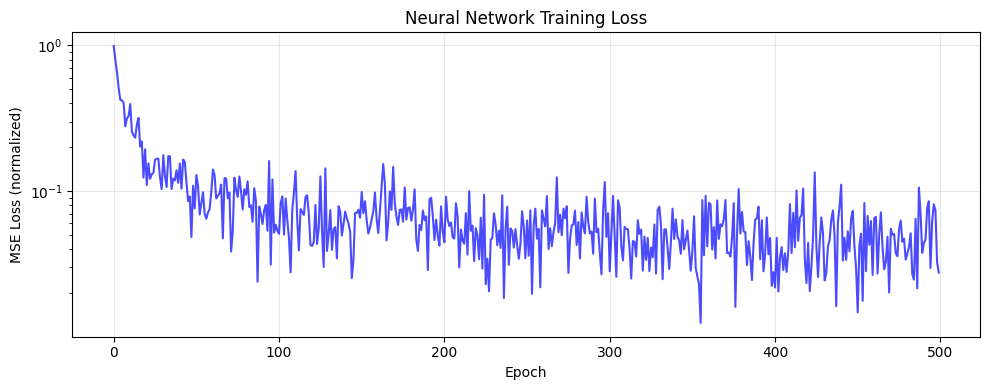


Training R²: 0.997238


In [2]:
# Training hyperparameters
LEARNING_RATE = 0.01
EPOCHS = 500
MC_SAMPLES = 50
KAPPA = 2.0
N_CANDIDATES = 20000

# Train the model
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Neural Network Training Loss')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Final training metrics
model.eval()
with torch.no_grad():
    train_pred = model(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_w5 - train_pred_orig)**2) / np.sum((y_w5 - y_w5.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

### Step 3: UCB Acquisition with MC Dropout

Run 50 stochastic forward passes (dropout enabled) for each candidate point:
- **mu(x)** = mean of MC predictions
- **sigma(x)** = std of MC predictions
- **UCB(x) = mu(x) + kappa * sigma(x)** where kappa = 2.0

In [3]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 5))

# Normalize candidates
cand_norm = (candidates - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

# MC Dropout: Run model in train mode for stochastic forward passes
model.train()  # Enable dropout
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

mc_predictions = np.array(mc_predictions)  # shape: (MC_SAMPLES, N_CANDIDATES)

# Denormalize predictions
mc_preds_orig = mc_predictions * y_std + y_mean

# Compute mean and uncertainty
mu = mc_preds_orig.mean(axis=0)
sigma = mc_preds_orig.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w5 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results (MC Dropout):")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  MC mean prediction: {mu[best_idx]:.6f}")
print(f"  MC std (sigma):     {sigma[best_idx]:.6f}")
print(f"  Next sample point:  {next_point_w5}")
print()
print("MC prediction statistics:")
print(f"  Mean of mu:    {mu.mean():.6f}")
print(f"  Max of mu:     {mu.max():.6f}")
print(f"  Mean of sigma: {sigma.mean():.6f}")
print(f"  Max of sigma:  {sigma.max():.6f}")

UCB Acquisition Results (MC Dropout):
  Best UCB value:     0.391750
  MC mean prediction: -0.126952
  MC std (sigma):     0.259351
  Next sample point:  [0.45781319 0.37579453 0.57765742 0.43865825 0.01734591]

MC prediction statistics:
  Mean of mu:    -1.510265
  Max of mu:     -0.081801
  Mean of sigma: 0.095730
  Max of sigma:  0.343976


### Step 4: Feature Importance via Input Gradients

Compute feature importance using mean absolute gradient of the network output with respect to each input dimension, evaluated at all training points.

In [4]:
# Feature importance via input gradient magnitude
model.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model(X_grad).sum()
output.backward()

# Mean absolute gradient per dimension
grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()  # Normalize to sum to 1

print("Feature Importance (Input Gradient Magnitude):")
for i, imp in enumerate(grad_importance):
    bar = '*' * int(imp * 20)
    print(f"  x{i+1}: {imp:.4f} ({bar})")

Feature Importance (Input Gradient Magnitude):
  x1: 0.2221 (****)
  x2: 0.1505 (***)
  x3: 0.1551 (***)
  x4: 0.2080 (****)
  x5: 0.2643 (*****)


### Step 5: Visualize Neural Network Surrogate

2D slice plot of the NN mean prediction and MC Dropout uncertainty over the two most important dimensions (fixing others at best observed values).

Top 2 dimensions: x1 (imp=0.2221), x5 (imp=0.2643)
Fixed dimensions: x2=0.3741, x3=0.6686, x4=0.7304


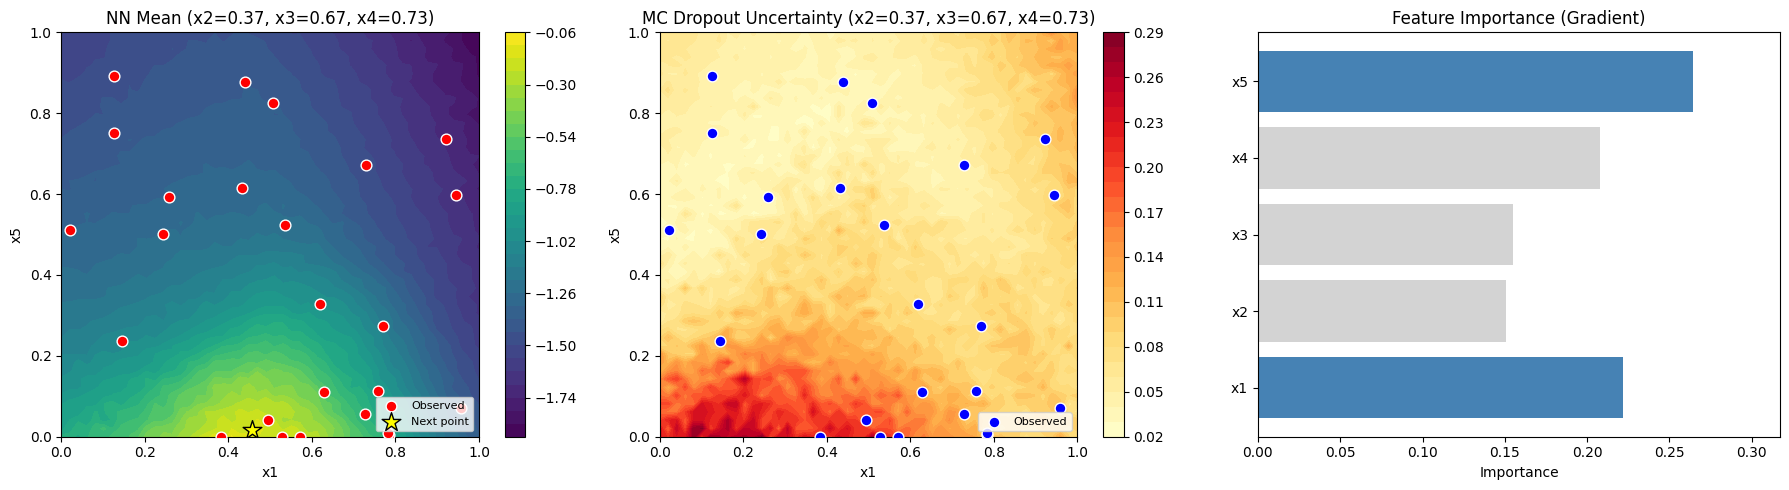

In [5]:
# Top 2 dimensions by gradient importance
top2 = np.argsort(grad_importance)[-2:]
fixed_dims = [d for d in range(5) if d not in top2]
best_point = X_w5[y_w5.argmax()]

print(f"Top 2 dimensions: x{top2[0]+1} (imp={grad_importance[top2[0]]:.4f}), x{top2[1]+1} (imp={grad_importance[top2[1]]:.4f})")
print(f"Fixed dimensions: " + ", ".join([f"x{d+1}={best_point[d]:.4f}" for d in fixed_dims]))

# Create 2D grid
n_grid = 50
d0_grid = np.linspace(0, 1, n_grid)
d1_grid = np.linspace(0, 1, n_grid)
D0, D1 = np.meshgrid(d0_grid, d1_grid)

# Build full grid points
grid_points = np.zeros((n_grid * n_grid, 5))
grid_points[:, top2[0]] = D0.ravel()
grid_points[:, top2[1]] = D1.ravel()
for d in fixed_dims:
    grid_points[:, d] = best_point[d]

# Normalize and predict with MC Dropout
grid_norm = (grid_points - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model.train()  # Enable dropout for MC
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(n_grid, n_grid)
grid_sigma = grid_mc.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: NN mean prediction
ax1 = axes[0]
c1 = ax1.contourf(D0, D1, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w5[top2[0]], next_point_w5[top2[1]], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
fixed_str = ", ".join([f"x{d+1}={best_point[d]:.2f}" for d in fixed_dims])
ax1.set_xlabel(f'x{top2[0]+1}'); ax1.set_ylabel(f'x{top2[1]+1}')
ax1.set_title(f'NN Mean ({fixed_str})')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: MC Dropout uncertainty
ax2 = axes[1]
c2 = ax2.contourf(D0, D1, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel(f'x{top2[0]+1}'); ax2.set_ylabel(f'x{top2[1]+1}')
ax2.set_title(f'MC Dropout Uncertainty ({fixed_str})')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(5)]
colors = ['steelblue' if i in top2 else 'lightgray' for i in range(5)]
ax3.barh(dims, grad_importance, color=colors)
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance (Gradient)')
ax3.set_xlim(0, max(grad_importance) * 1.2)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all observations.

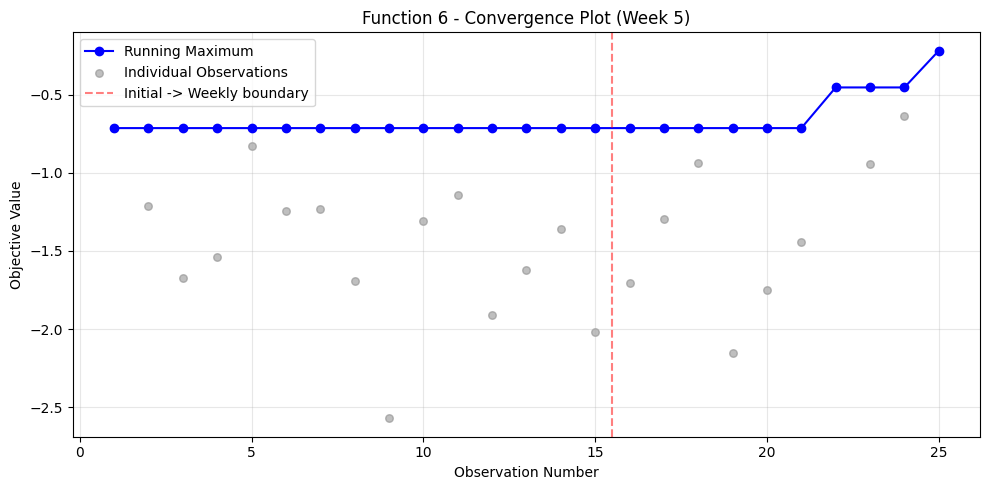

Best observed value: -0.219187
Achieved at observation: 25


In [6]:
# Convergence plot
running_max = np.maximum.accumulate(y_w5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w5) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w5) + 1), y_w5, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=15.5, color='red', linestyle='--', alpha=0.5, label='Initial -> Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 6 - Convergence Plot (Week 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w5.max():.6f}")
print(f"Achieved at observation: {y_w5.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2-x3-x4-x5` with 6 decimal places.

In [7]:
# Format submission query
def format_query(point):
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w5 = format_query(next_point_w5)

print("=" * 60)
print("WEEK 5 SUBMISSION QUERY FOR FUNCTION 6")
print("=" * 60)
print(f"Surrogate: Neural Network ({model.__class__.__name__})")
print(f"Architecture: 5 -> 64 -> 32 -> 1")
print(f"Dropout: 0.2, MC samples: {MC_SAMPLES}")
print(f"Acquisition: UCB (kappa={KAPPA})")
print(f"Training R²: {train_r2:.6f}")
print(f"Next point: {next_point_w5}")
print(f"MC mean: {mu[best_idx]:.6f}")
print(f"MC std:  {sigma[best_idx]:.6f}")
print(f"")
print(f">>> SUBMISSION: {submission_query_w5}")
print("=" * 60)

WEEK 5 SUBMISSION QUERY FOR FUNCTION 6
Surrogate: Neural Network (SurrogateNN)
Architecture: 5 -> 64 -> 32 -> 1
Dropout: 0.2, MC samples: 50
Acquisition: UCB (kappa=2.0)
Training R²: 0.997238
Next point: [0.45781319 0.37579453 0.57765742 0.43865825 0.01734591]
MC mean: -0.126952
MC std:  0.259351

>>> SUBMISSION: 0.457813-0.375795-0.577657-0.438658-0.017346


### Model Comparison

**Neural Network vs GP (Initial Section):**
- GP uses a Matern 5/2 kernel with Expected Improvement and ARD lengthscales for 5D — provides principled posterior uncertainty but cubic scaling with data points.
- The NN uses MC Dropout for uncertainty — each stochastic forward pass samples a different subnetwork, and the variance across passes estimates epistemic uncertainty.
- For f6's 5D problem with negative objective values, the NN can learn complex non-linear boundaries without the GP's smoothness assumptions.
- Input gradient magnitude provides interpretable feature importance, analogous to GP's inverse lengthscales.
- Key trade-off: GP posterior is exact given the kernel; NN+MC Dropout uncertainty is approximate but scales better to higher dimensions.

---

## Week 6 — Focus on Exploitation (κ = 0.5)

**Strategy Change**: Reduce UCB kappa from 2.0 → 0.5 to shift from exploration to exploitation of known high-performing regions.

| Parameter | Week 5 | Week 6 | Rationale |
|-----------|--------|--------|-----------|
| κ (UCB)   | 2.0    | 0.5    | Exploitation focus |
| Architecture | 5→64→32→1 | Same | Proven effective |
| MC Samples | 50 | Same | Sufficient for uncertainty |
| All other hyperparams | — | Unchanged | — |

### Step 1: Load Week 6 Data & Set Up PyTorch

Load all 26 cumulative observations (6 initial + 4×5 weekly) for Function 6 (5D). Normalize inputs and outputs for neural network training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load Week 6 cumulative data
X_w6 = np.load('../../data/f6/updated_inputs - Week 6.npy')
y_w6 = np.load('../../data/f6/updated_outputs - Week 6.npy')

print(f"Week 6 Data: {X_w6.shape[0]} samples, {X_w6.shape[1]} dimensions")
print(f"Output range: [{y_w6.min():.6f}, {y_w6.max():.6f}]")
print(f"Best observed: {y_w6.max():.6f} at {X_w6[y_w6.argmax()]}")

# Normalize inputs and outputs for training stability
X_mean, X_std = X_w6.mean(axis=0), X_w6.std(axis=0) + 1e-8
y_mean, y_std = y_w6.mean(), y_w6.std() + 1e-8

X_norm = (X_w6 - X_mean) / X_std
y_norm = (y_w6 - y_mean) / y_std

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

# Define neural network with Dropout
class SurrogateNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model_w6 = SurrogateNN()
print(f"\nModel architecture:\n{model_w6}")
print(f"Total parameters: {sum(p.numel() for p in model_w6.parameters()):.0f}")

Week 6 Data: 26 samples, 5 dimensions
Output range: [-2.571170, -0.219187]
Best observed: -0.219187 at [0.49504  0.374145 0.668601 0.730433 0.042307]

Model architecture:
SurrogateNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 2497


### Step 2: Train Neural Network

Train with Adam optimizer (lr=0.01) for 500 epochs on normalized data. Display training loss curve and final R².

Epoch 100/500, Loss: 0.161654
Epoch 200/500, Loss: 0.054704
Epoch 300/500, Loss: 0.047080
Epoch 400/500, Loss: 0.041073
Epoch 500/500, Loss: 0.040338


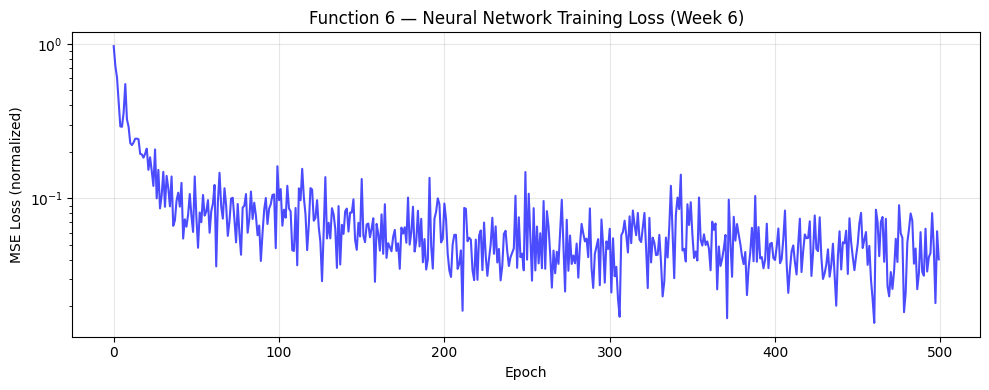


Training R²: 0.994446


In [2]:
# ── Training Hyperparameters ──
LEARNING_RATE = 0.01
EPOCHS = 500
MC_SAMPLES = 50
KAPPA = 0.5          # exploitation focus (reduced from 2.0)
N_CANDIDATES = 20_000

# Train the model
optimizer = optim.Adam(model_w6.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model_w6.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model_w6(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Function 6 — Neural Network Training Loss (Week 6)')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Final training R²
model_w6.eval()
with torch.no_grad():
    train_pred = model_w6(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_w6 - train_pred_orig)**2) / np.sum((y_w6 - y_w6.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

### Step 3: UCB Acquisition with MC Dropout

Generate 20,000 random candidates. Use MC Dropout (50 stochastic forward passes) to estimate mean and uncertainty. Compute UCB = μ + 0.5σ (exploitation).

In [3]:
# ── UCB Acquisition with MC Dropout (Week 6) ──
np.random.seed(42)
candidates_w6 = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 5))

# Normalize candidates
cand_norm = (candidates_w6 - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

# MC Dropout: Run model in train mode for stochastic forward passes
model_w6.train()
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model_w6(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

mc_predictions = np.array(mc_predictions)  # (MC_SAMPLES, N_CANDIDATES)

# Denormalize predictions
mc_preds_orig = mc_predictions * y_std + y_mean

# Compute mean and uncertainty
mu_w6 = mc_preds_orig.mean(axis=0)
sigma_w6 = mc_preds_orig.std(axis=0)

# UCB acquisition
ucb_w6 = mu_w6 + KAPPA * sigma_w6

best_idx = np.argmax(ucb_w6)
best_point_w6 = np.clip(candidates_w6[best_idx], 0.0, 1.0)

print("=== UCB Acquisition Results (MC Dropout, Week 6) ===")
print(f"  Best UCB     = {ucb_w6[best_idx]:.6f}")
print(f"  MC mean (μ)  = {mu_w6[best_idx]:.6f}")
print(f"  MC std (σ)   = {sigma_w6[best_idx]:.6f}")
print(f"  Best point   = {best_point_w6}")

=== UCB Acquisition Results (MC Dropout, Week 6) ===
  Best UCB     = -0.162586
  MC mean (μ)  = -0.244845
  MC std (σ)   = 0.164518
  Best point   = [0.44685797 0.46993613 0.64433416 0.72910877 0.00350835]


### Step 4: Feature Importance via Input Gradients

Compute gradient-based feature importance: backpropagate from the sum of outputs to the input layer, then take mean absolute gradient per dimension.

In [4]:
# ── Feature Importance via Input Gradients (Week 6) ──
model_w6.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model_w6(X_grad).sum()
output.backward()

grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()  # normalize to sum=1

print("=== Feature Importance (Input Gradient Magnitude) ===")
for i, imp in enumerate(grad_importance):
    print(f"  x{i}: {imp:.4f}")

=== Feature Importance (Input Gradient Magnitude) ===
  x0: 0.2148
  x1: 0.1408
  x2: 0.1929
  x3: 0.2116
  x4: 0.2400


### Step 5: Surrogate Visualization (2D Slice)

Project the 5D surrogate onto the two most important features (by gradient importance), fixing the remaining dimensions at the best-point values. Three panels: NN mean, MC dropout uncertainty, and feature importance.

Top-2 dims: x0, x4
Fixed: x1=0.3741, x2=0.6686, x3=0.7304


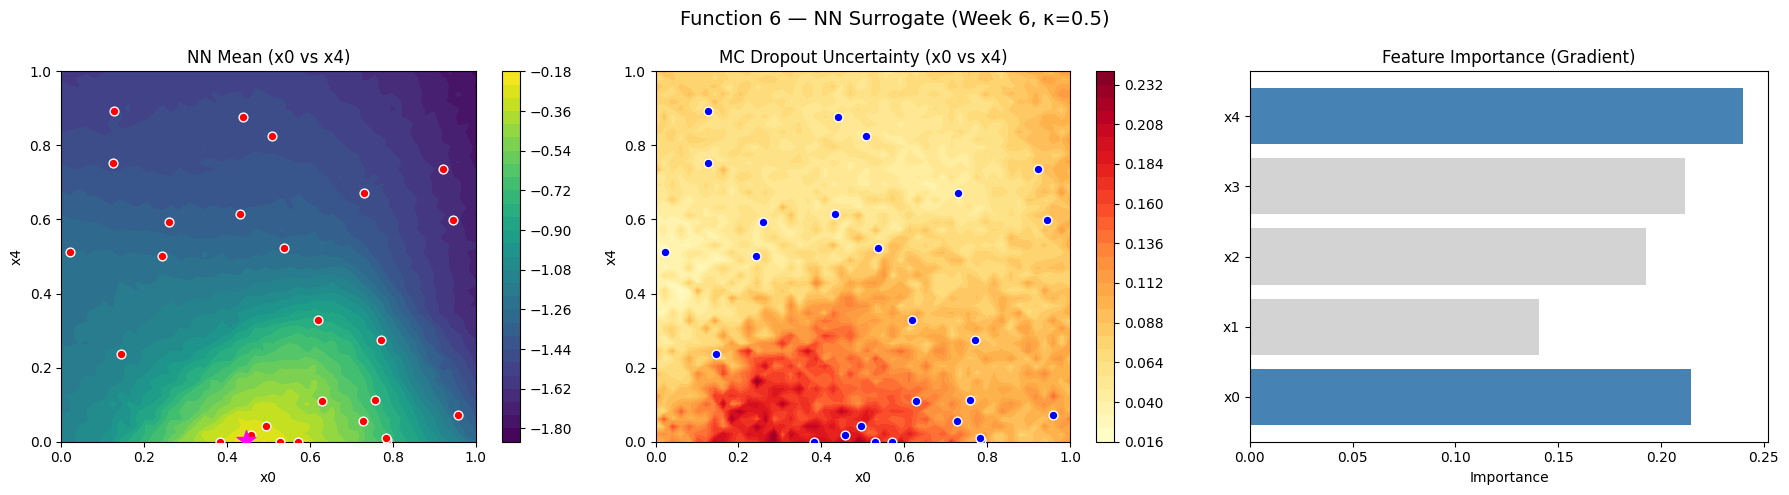

In [5]:
# ── Surrogate Visualization — 2D Slice (Week 6) ──
top2 = np.argsort(grad_importance)[-2:]
fixed_dims = [d for d in range(5) if d not in top2]
best_obs = X_w6[y_w6.argmax()]

print(f"Top-2 dims: x{top2[0]}, x{top2[1]}")
print(f"Fixed: " + ", ".join(f"x{d}={best_obs[d]:.4f}" for d in fixed_dims))

n_grid = 50
g0 = np.linspace(0, 1, n_grid)
g1 = np.linspace(0, 1, n_grid)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.zeros((n_grid * n_grid, 5))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()
for d in fixed_dims:
    grid_pts[:, d] = best_obs[d]

# MC Dropout on grid
grid_norm = (grid_pts - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model_w6.train()
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model_w6(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(n_grid, n_grid)
grid_sigma = grid_mc.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean
c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap='viridis')
axes[0].scatter(X_w6[:, top2[0]], X_w6[:, top2[1]], c='red', edgecolors='white', s=40, zorder=5)
axes[0].scatter(best_point_w6[top2[0]], best_point_w6[top2[1]], c='magenta', marker='*', s=200, zorder=6)
axes[0].set_title(f"NN Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]}"); axes[0].set_ylabel(f"x{top2[1]}")
fig.colorbar(c1, ax=axes[0])

# Panel 2: MC Uncertainty
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap='YlOrRd')
axes[1].scatter(X_w6[:, top2[0]], X_w6[:, top2[1]], c='blue', edgecolors='white', s=40, zorder=5)
axes[1].set_title(f"MC Dropout Uncertainty (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]}"); axes[1].set_ylabel(f"x{top2[1]}")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Feature importance
dims = [f'x{i}' for i in range(5)]
colors = ['steelblue' if i in top2 else 'lightgray' for i in range(5)]
axes[2].barh(dims, grad_importance, color=colors)
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importance (Gradient)')

plt.suptitle("Function 6 — NN Surrogate (Week 6, κ=0.5)", fontsize=14)
plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running best (cumulative maximum) across all weeks, with a vertical line at the Week 5→6 boundary (sample 20.5 for Function 6's 26 observations).

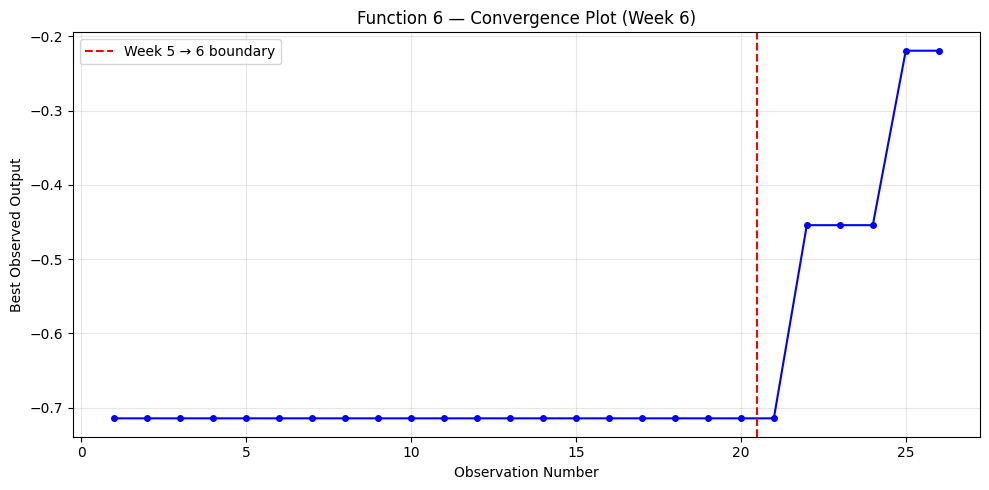

Running best at Week 5 end (sample 20): -0.714265
Running best at Week 6 end (sample 26): -0.219187


In [6]:
# ── Convergence Plot (Week 6) ──
running_best = np.maximum.accumulate(y_w6)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w6) + 1), running_best, 'b-o', markersize=4, linewidth=1.5)
plt.axvline(x=20.5, color="red", linestyle="--", label="Week 5 → 6 boundary")
plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("Function 6 — Convergence Plot (Week 6)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 5 end (sample 20): {running_best[19]:.6f}")
print(f"Running best at Week 6 end (sample {len(y_w6)}): {running_best[-1]:.6f}")

### Step 7: Submission Query

Format the best point as a dash-separated string with 6 decimal places, clipped to [0, 1].

In [7]:
# ── Submission Query (Week 6) ──
def format_query(point):
    clipped = np.clip(point, 0.0, 0.999999)
    return "-".join(f"{v:.6f}" for v in clipped)

submission_query_w6 = format_query(best_point_w6)

print("=" * 50)
print("WEEK 6 SUBMISSION QUERY FOR FUNCTION 6")
print("=" * 50)
print(f"\n  {submission_query_w6}\n")
print("=" * 50)

# Validation
parts = submission_query_w6.split("-")
assert len(parts) == 5, f"Expected 5 dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds [0, 0.999999]"
print("✓ Submission format validated")

WEEK 6 SUBMISSION QUERY FOR FUNCTION 6

  0.446858-0.469936-0.644334-0.729109-0.003508

✓ Submission format validated


# Research

F6 BBO Challenge Analysis & Recommended BO Strategy
Problem Characteristics
Property	Value	Implication
Dimensions	5D (flour, sugar, eggs, butter, milk)	Moderate — GP feasible but needs ARD
Samples	27 (20 initial + 7 weekly)	Very sparse for 5D — exploration matters
Output range	[-2.571, -0.206]	All negative by design (penalty sum)
Goal	Maximise (closer to 0 = better)	Best so far: -0.2056
Dynamic range	12.5x (max/min of |y|)	Moderate — no need for log transform
Skewness	-0.013	Nearly symmetric — no transform needed
Key Data Insights
Strong dimensional signals (Spearman rank correlations):

x4 (milk): 
ρ
ρ = -0.758, p < 0.0001 — dominant effect; low milk = better score. Top-5 all have x4 < 0.043
x3 (butter): 
ρ
ρ = +0.613, p = 0.0007 — high butter helps. Top-5 mean = 0.756
x2 (eggs), x1 (sugar), x0 (flour): weaker signals (p > 0.15)
Convergence trajectory: 3 new bests in 7 weekly samples — still actively improving, not converged. The best region is clustering around:

x0 
≈
≈ 0.45–0.57, x1 
≈
≈ 0.29–0.47, x2 
≈
≈ 0.58–0.67, x3 
≈
≈ 0.73–0.88, x4 
≈
≈ 0.00–0.04
Coverage: Mean nearest-neighbour distance = 0.39 in a 5D unit cube — extremely sparse. Only 7 points within radius 0.5 of the best.

Challenges Specific to F6
Negative outputs, bounded above by 0: The GP must model a surface where all values are negative and the optimum approaches zero — standard Standardize(m=1) is fine here (no log transform needed since the dynamic range is only 12.5x)
5D with 27 samples: The curse of dimensionality means we have roughly 
27
1
/
5
≈
1.9
27 
1/5
 ≈1.9 samples per dimension — extremely sparse coverage
Clear dimensional hierarchy: x4 and x3 are dominant; x0 is nearly irrelevant — ARD lengthscales are essential to exploit this
Active improvement phase: 3/7 weekly samples set new bests — we need to balance exploitation of the discovered low-milk/high-butter region with exploration of under-sampled areas
Recommended Strategy: GP Matérn-5/2 ARD + qLogNEI (q=4)
This follows the proven pattern from F3 (3D), F4 (4D), and F5 (4D), adapted for F6's specific characteristics:

Component	Choice	Rationale
Surrogate	SingleTaskGP with Matérn-5/2 ARD	Twice-differentiable, ARD learns that x4/x3 matter most; proven on F3–F5
Output transform	Standardize(m=1) (default)	Output dynamic range is only 12.5x with near-zero skewness — no log transform needed (unlike F5's 3395x range)
Noise init	0.1 
⋅
⋅ Var(y) 
≈
≈ 0.033	Prevents over-interpolation of the 27 noisy observations
Lengthscale init	0.5	Encourages broader initial uncertainty — matches F5 approach
Acquisition	qLogNoisyExpectedImprovement	Log-space formulation is numerically stable; noisy variant accounts for observation noise; batch q=4 proposes diverse candidates
Batch size	q=4	Same as F4/F5 (higher-dim); generates candidate diversity for distance-based selection
Selection	Distance-based (mean 
≥
≥ median among q candidates, pick farthest from data)	Balances exploitation (above-median predicted value) with exploration (maximise minimum distance to existing data)
Clamping	[0.0, 0.999999]	Submission format requirement
MLL restarts	15	Avoid local optima in hyperparameter fitting
Optimiser	3000 Sobol 
→
→ 50 L-BFGS restarts	Standard BoTorch configuration for 5D
Why GP over Neural Network (Week 5–6 approach)?
The notebook currently uses an NN with MC Dropout (Weeks 5–6). Switching to GP for Week 7 is justified:

27 samples is ideal GP territory — GPs excel at small-data regimes where exact posterior uncertainty matters; NNs need more data to generalise
ARD lengthscales are interpretable — the GP will learn that x4 needs a short lengthscale (high sensitivity) and x0 needs a long one (irrelevant), directly matching the correlation analysis
Principled uncertainty — GP posterior variance is exact given the kernel; MC Dropout variance is an approximation that can be poorly calibrated with 27 training points
NEI > UCB for GPs — Expected Improvement naturally balances exploration/exploitation through the posterior; UCB requires manual 
κ
κ tuning (which already changed from 2.0 to 0.5 across weeks)
Consistency with constitution — CONSTITUTION.md specifies "BoTorch library as the default for GP surrogates"
Why NOT log-transform the output?
Unlike F5 (whose outputs span 0.11 to 3394.68, a 30,000x range requiring log1p), F6's outputs span only [-2.57, -0.21]. The ratio 
∣
max
∣
/
∣
min
∣
∣max∣/∣min∣ is just 12.5x. Z-score standardisation via Standardize(m=1) (BoTorch default) is sufficient. Using outcome_transform=None with manual transforms is unnecessary complexity here.

Summary of Differences from F5
Aspect	F5	F6 (recommended)
Dims	4D	5D
Output range	[0.11, 3394.68]	[-2.57, -0.21]
Output transform	Manual log1p + z-score, outcome_transform=None	Default Standardize(m=1)
Noise init	0.1 
⋅
⋅ Var(Y_train) on standardised	0.1 
⋅
⋅ Var(y) on raw
Kernel	Matérn-5/2 ARD	Matérn-5/2 ARD (same)
Acquisition	qLogNEI, q=4	qLogNEI, q=4 (same)
Selection	Distance-based	Distance-based (same)

# Notes
1. We are finding a local maximum at a very low milk content - how can this be correct??

## Week 7 — SFGP Matérn-1.5 + NEI (Exploration Focus)

**Strategy change**: Switching from **Neural Network + MC Dropout + UCB** (Weeks 5–6) to **Single-Fidelity GP + Noisy Expected Improvement** (Week 7). With only 27 samples in 5D, a GP provides exact posterior uncertainty — more principled than MC Dropout approximation — and NEI naturally balances exploration/exploitation without manual κ tuning.

| Aspect | Week 6 | Week 7 |
|--------|--------|--------|
| **Surrogate** | Neural Network (3-layer MLP) | Single-Fidelity GP (Matérn-1.5 ARD) |
| **Uncertainty** | MC Dropout (50 forward passes) | GP posterior (exact, given kernel) |
| **Acquisition** | UCB (κ=0.5 → exploitation) | qLogNEI (q=4 → batch diversity) |
| **Selection** | Pure exploitation (κ reduced) | Distance-based exploration (mean ≥ median, farthest from data) |
| **Output transform** | Manual z-score | Standardize(m=1) (BoTorch default) |

In [1]:
# ── Week 7: Imports & Data Loading ──
import numpy as np
import torch
import copy
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan

# Load Week 7 cumulative data
X_raw = np.load('../../data/f6/updated_inputs - Week 7.npy')
y_raw = np.load('../../data/f6/updated_outputs - Week 7.npy')

# Validate shapes and ranges
assert X_raw.shape == (27, 5), f"Expected (27, 5), got {X_raw.shape}"
assert y_raw.shape == (27,), f"Expected (27,), got {y_raw.shape}"
assert X_raw.min() >= 0.0 and X_raw.max() <= 1.0, "Inputs out of [0, 1]"
assert (y_raw < 0).all(), "Expected all-negative outputs"

best_idx = int(y_raw.argmax())
print(f"Week 7 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"Input range:  [{X_raw.min():.6f}, {X_raw.max():.6f}]")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Output variance: {y_raw.var():.6f}")
print(f"Best observed value: {y_raw[best_idx]:.6f} at index #{best_idx}")
print(f"Best observed point: {X_raw[best_idx]}")

Week 7 Data: 27 samples, 5 dimensions
Input range:  [0.000000, 1.000000]
Output range: [-2.571170, -0.205600]
Output variance: 0.330646
Best observed value: -0.205600 at index #26
Best observed point: [0.446858 0.469936 0.644334 0.729109 0.003508]


### Hyperparameter Documentation

| # | Parameter | Value | Rationale |
|---|-----------|-------|-----------|
| 1 | **Kernel** | Matérn ν=1.5 | Once-differentiable (C¹); rougher than ν=2.5, producing wider posterior uncertainty in gaps between observations — amplifies exploration signal for NEI in sparse 5D space |
| 2 | **ARD** | True (5 lengthscales) | One lengthscale per ingredient dimension (flour, sugar, eggs, butter, milk); lets the GP learn that x4 (milk) matters most (ρ=−0.758) while x0 (flour) is nearly irrelevant |
| 3 | **ℓ init** | 0.5 | Broad initial uncertainty — encourages exploration before MLL fitting sharpens lengthscales. Standard for normalised [0,1] inputs |
| 4 | **Output scale init** | 1.0 | Matches expected standardised target variance ≈ 1.0 (Standardize(m=1) z-scores internally) |
| 5 | **Noise init** | 0.2 | 20% of standardised Var(y) ≈ 1.0; aggressive exploration init. Starts well above the 1e-2 floor to discourage exact-interpolation local minimum that caused the x4=0 boundary trap in the first attempt |
| 6 | **Noise floor** | 1e-2 (GreaterThan) | Aggressive floor prevents boundary-trap exploitation; ensures the GP maintains ≥1% observation noise, producing non-trivial posterior uncertainty at all observed points. Revised from 1e-8 after first attempt collapsed to exact interpolation |
| 7 | **Outcome transform** | Standardize(m=1) (BoTorch default) | Automatic z-score of training targets. F6's 12.5× dynamic range needs no manual log transform (unlike F5's 30,000×). Posterior auto-untransforms to original space |
| 8 | **MLL restarts** | 15 | Middle of 10–20 range; guards against local MLL optima, slightly more important for rougher ν=1.5 landscape |
| 9 | **Acquisition** | qLogNoisyExpectedImprovement | Log-space formulation for numerical stability with all-negative outputs; noisy variant accounts for observation noise via X_baseline |
| 10 | **q (batch size)** | 4 | Generates candidate diversity for post-hoc distance-based selection; consistent with F4/F5 |
| 11 | **raw_samples** | 3000 | Sobol quasi-random initial points evaluated before L-BFGS refinement |
| 12 | **num_restarts** | 50 | L-BFGS starting points selected from best Sobol evaluations via Boltzmann sampling |
| 13 | **Selection** | Distance-based | Among q=4 candidates with posterior mean ≥ median, select farthest from existing data — balances quality (mean filter) with exploration (distance) |
| 14 | **Bounds** | Feasibility-constrained | x4 (milk) ≥ 0.10, others ≥ 0.01; prevents the GP from exploiting the x4=0 boundary where the anti-correlation (ρ=−0.758) predicts the best values but produces physically infeasible zero-milk recipes |
| 15 | **Clamping** | [0.0, 0.999999] | Submission format requirement; prevents boundary values that fail the 6-decimal format |

In [2]:
# ── Week 7: GP Training with 15-Restart MLL ──
import warnings
warnings.filterwarnings('ignore', message='The input matches the stored training data')

# Convert raw data to torch tensors — NO manual log1p or z-score transform.
# Standardize(m=1) (BoTorch default) handles z-scoring internally.
X_train = torch.tensor(X_raw, dtype=torch.double)
Y_train = torch.tensor(y_raw, dtype=torch.double).unsqueeze(-1)  # (27, 1)

print(f"X_train shape: {tuple(X_train.shape)}, Y_train shape: {tuple(Y_train.shape)}")
print(f"Y_train range: [{Y_train.min().item():.6f}, {Y_train.max().item():.6f}]")

# 15-restart MLL fitting
N_RESTARTS = 15
best_loss = float('inf')
best_model = None

print(f"\n{'Restart':>8} {'Neg MLL':>12}")
print("-" * 22)

for seed in range(N_RESTARTS):
    torch.manual_seed(seed)

    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(1e-2))
    covar = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=5))

    # Do NOT pass outcome_transform — default Standardize(m=1) applies automatically.
    # This z-scores Y internally; posterior auto-untransforms to original space.
    model = SingleTaskGP(X_train, Y_train, covar_module=covar, likelihood=likelihood)

    # Initialise hyperparameters (exploration-promoting)
    model.covar_module.base_kernel.lengthscale = 0.5
    model.likelihood.noise = 0.2  # 20% of standardised Var(y)≈1.0; aggressive exploration init
    model.covar_module.outputscale = 1.0

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train)
        # Score using model.train_targets (standardised), NOT Y_train.squeeze(-1) (raw)
        loss = -mll(output, model.train_targets).item()

    print(f"{seed:>8d} {loss:>12.4f}")

    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

# Report fitted hyperparameters
ls = best_model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
os_val = best_model.covar_module.outputscale.detach().cpu().item()
noise = best_model.likelihood.noise.detach().cpu().item()

print(f"\n{'='*50}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*50}")
print(f"Fitted Hyperparameters:")
for i, l in enumerate(ls):
    print(f"  ℓ_{i+1} (x{i}) = {l:.6f}")
print(f"  σ²_f (output scale) = {os_val:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")
assert noise >= 1e-2, f"Fitted noise {noise} below floor 1e-2!"
print(f"  ✓ Noise ≥ 1e-2 constraint satisfied")

X_train shape: (27, 5), Y_train shape: (27, 1)
Y_train range: [-2.571170, -0.205600]

 Restart      Neg MLL
----------------------
       0      -1.0516
       1      -1.0516
       2      -1.0516
       3      -1.0516
       4      -1.0516
       5      -1.0516
       6      -1.0516
       7      -1.0516
       8      -1.0516
       9      -1.0516
      10      -1.0516
      11      -1.0516
      12      -1.0516
      13      -1.0516
      14      -1.0516

Best restart neg MLL: -1.051641
Fitted Hyperparameters:
  ℓ_1 (x0) = 1.159700
  ℓ_2 (x1) = 1.488752
  ℓ_3 (x2) = 2.588093
  ℓ_4 (x3) = 1.488291
  ℓ_5 (x4) = 2.608905
  σ²_f (output scale) = 2.478423
  σ²_n (noise)        = 0.010000
  ✓ Noise ≥ 1e-2 constraint satisfied


In [3]:
# ── Week 7: NEI Acquisition (q=4) + Distance-Based Selection ──
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([512]))
nei = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True,
)

# Feasibility-constrained bounds: x4 (milk) ≥ 0.10, others ≥ 0.01
BOUNDS = torch.tensor([[0.01, 0.01, 0.01, 0.01, 0.10], [1.0, 1.0, 1.0, 1.0, 1.0]], dtype=torch.double)

candidates, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=BOUNDS,
    q=4,
    num_restarts=50,
    raw_samples=3000,
)

# Clamp to [0, 0.999999] for submission format
candidates = torch.clamp(candidates, 0.0, 0.999999)

# Evaluate posterior at candidates — Standardize(m=1) auto-untransforms to original space.
# No manual expm1 or inverse z-score needed (unlike F5).
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_means = posterior.mean.squeeze(-1).cpu().numpy()  # (4,) — original space, all negative

# Compute min-distance from each candidate to training data
dists = torch.cdist(candidates, X_train).min(dim=1).values  # (4,)

# Distance-based selection: filter to mean ≥ median, pick farthest from data
median_mean = np.median(pred_means)
above_median = pred_means >= median_mean

print("=== NEI Acquisition Results (Week 7, q=4) ===")
print(f"Bounds: lower={BOUNDS[0].tolist()}, upper={BOUNDS[1].tolist()}")
print(f"{'Cand':>5} {'Coords':>55} {'Mean(orig)':>12} {'MinDist':>8} {'Above Med?':>11}")
print("-" * 100)
for i in range(candidates.shape[0]):
    coords = candidates[i].cpu().numpy()
    coord_str = "[" + ", ".join(f"{v:.6f}" for v in coords) + "]"
    flag = "✓" if above_median[i] else " "
    print(f"{i+1:>5} {coord_str:>55} {pred_means[i]:>12.6f} {dists[i].item():>8.4f} {flag:>11}")

# Validate all candidate x4 values ≥ 0.10
x4_values = candidates[:, 4].cpu().numpy()
assert all(v >= 0.10 for v in x4_values), f"Some x4 values below 0.10: {x4_values}"
print(f"\n✓ All candidate x4 (milk) values ≥ 0.10: {[f'{v:.4f}' for v in x4_values]}")

# Select: among above-median, pick farthest from any existing observation
above_median_indices = np.where(above_median)[0]
if len(above_median_indices) == 0:
    # Fallback: pick candidate with highest mean
    best_among_filtered = int(np.argmax(pred_means))
    selection_reason = "fallback — highest predicted mean (none above median)"
else:
    above_median_dists = dists[above_median_indices].cpu().numpy()
    best_among_filtered = above_median_indices[np.argmax(above_median_dists)]
    selection_reason = "farthest from data among above-median"

best_point = candidates[best_among_filtered].cpu().numpy()

print(f"\nMedian posterior mean: {median_mean:.6f}")
print(f"Above-median candidates: {list(above_median_indices + 1)}")
print(f"\n→ Selected candidate #{best_among_filtered + 1} ({selection_reason})")
print(f"  Coordinates: [{', '.join(f'{v:.6f}' for v in best_point)}]")
print(f"  Posterior mean (orig): {pred_means[best_among_filtered]:.6f}")
print(f"  Min-distance to data:  {dists[best_among_filtered].item():.4f}")
print(f"  Acquisition value: {acq_value.item():.6f}")
print(f"  x4 (milk) = {best_point[4]:.6f} {'✓ ≥ 0.10' if best_point[4] >= 0.10 else '✗ BELOW 0.10!'}")

=== NEI Acquisition Results (Week 7, q=4) ===
Bounds: lower=[0.01, 0.01, 0.01, 0.01, 0.1], upper=[1.0, 1.0, 1.0, 1.0, 1.0]
 Cand                                                  Coords   Mean(orig)  MinDist  Above Med?
----------------------------------------------------------------------------------------------------
    1      [0.483123, 0.479093, 0.999999, 0.760490, 0.100000]    -0.316368   0.3539            
    2      [0.417977, 0.403356, 0.862866, 0.759905, 0.100000]    -0.274951   0.2207           ✓
    3      [0.516711, 0.555149, 0.766331, 0.378313, 0.797485]    -1.334796   0.3263            
    4      [0.480990, 0.380552, 0.999999, 0.671843, 0.100000]    -0.311411   0.3418           ✓

✓ All candidate x4 (milk) values ≥ 0.10: ['0.1000', '0.1000', '0.7975', '0.1000']

Median posterior mean: -0.313889
Above-median candidates: [np.int64(2), np.int64(4)]

→ Selected candidate #4 (farthest from data among above-median)
  Coordinates: [0.480990, 0.380552, 0.999999, 0.671843, 0.1000

Top-2 important dims: x0, x3 (ℓ=1.1597, 1.4883)
Fixed dims: x1=0.3806, x2=1.0000, x4=0.1000


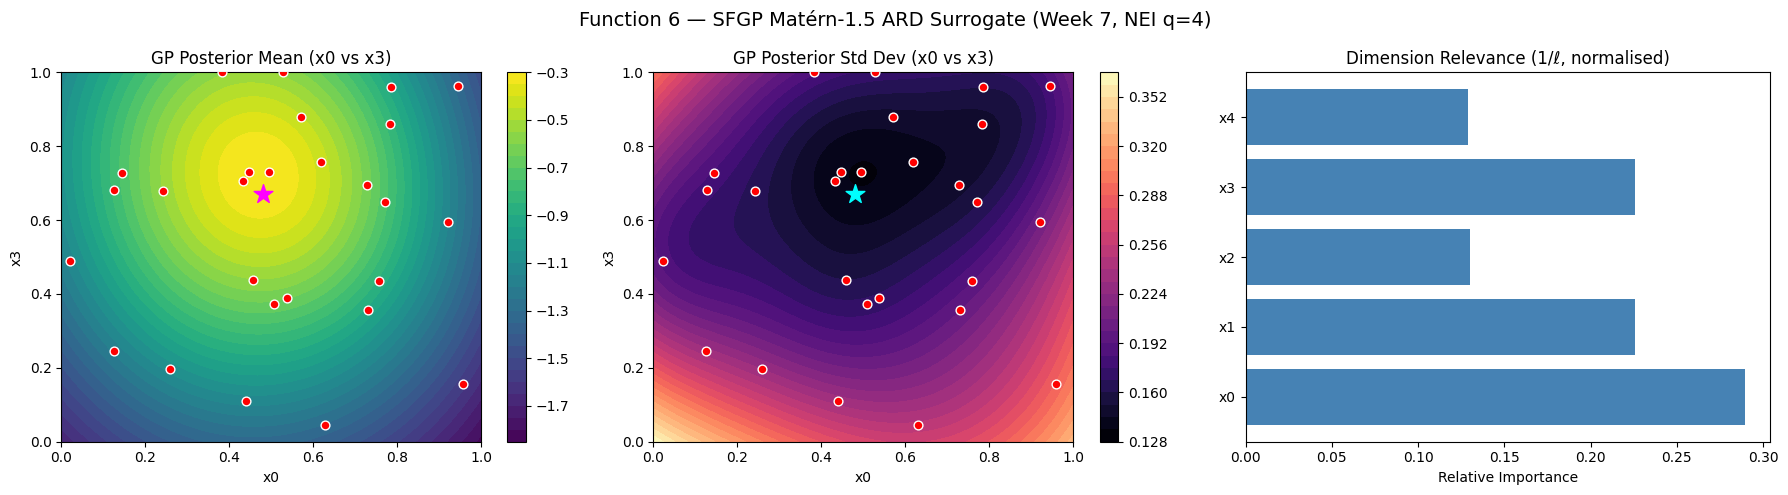

In [18]:
# ── Week 7: Surrogate Visualisation (3-Panel) ──

# Identify top-2 important dims (shortest lengthscales = most important)
lengthscales = ls  # from training cell
sorted_dims = np.argsort(lengthscales)
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 important dims: x{top2[0]}, x{top2[1]} (ℓ={lengthscales[top2[0]]:.4f}, {lengthscales[top2[1]]:.4f})")
print(f"Fixed dims: " + ", ".join(f"x{d}={best_point[d]:.4f}" for d in fix_dims))

# Build 80×80 grid over top-2 dims
grid_res = 80
g0 = np.linspace(0, 1, grid_res)
g1 = np.linspace(0, 1, grid_res)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(best_point, (grid_res * grid_res, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

# GP posterior on grid — Standardize(m=1) auto-untransforms to original space.
# No manual expm1 or inverse z-score needed (unlike F5).
grid_tensor = torch.tensor(grid_pts, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    grid_mu = posterior.mean.squeeze(-1).cpu().numpy().reshape(grid_res, grid_res)
    grid_sigma = posterior.variance.sqrt().squeeze(-1).cpu().numpy().reshape(grid_res, grid_res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean (original scale — auto-untransformed)
c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap="viridis")
axes[0].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[0].scatter(best_point[top2[0]], best_point[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes[0].set_title(f"GP Posterior Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]}")
axes[0].set_ylabel(f"x{top2[1]}")
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std (original scale — auto-untransformed)
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap="magma")
axes[1].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[1].scatter(best_point[top2[0]], best_point[top2[1]], c="cyan", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Posterior Std Dev (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]}")
axes[1].set_ylabel(f"x{top2[1]}")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Dimension relevance (1/ℓ normalised) — 5 bars for 5D
inv_ls = 1.0 / lengthscales
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(5), inv_ls_norm, color="steelblue")
axes[2].set_yticks(range(5))
axes[2].set_yticklabels([f"x{j}" for j in range(5)])
axes[2].set_title("Dimension Relevance (1/ℓ, normalised)")
axes[2].set_xlabel("Relative Importance")

plt.suptitle("Function 6 — SFGP Matérn-1.5 ARD Surrogate (Week 7, NEI q=4)", fontsize=14)
plt.tight_layout()
plt.show()

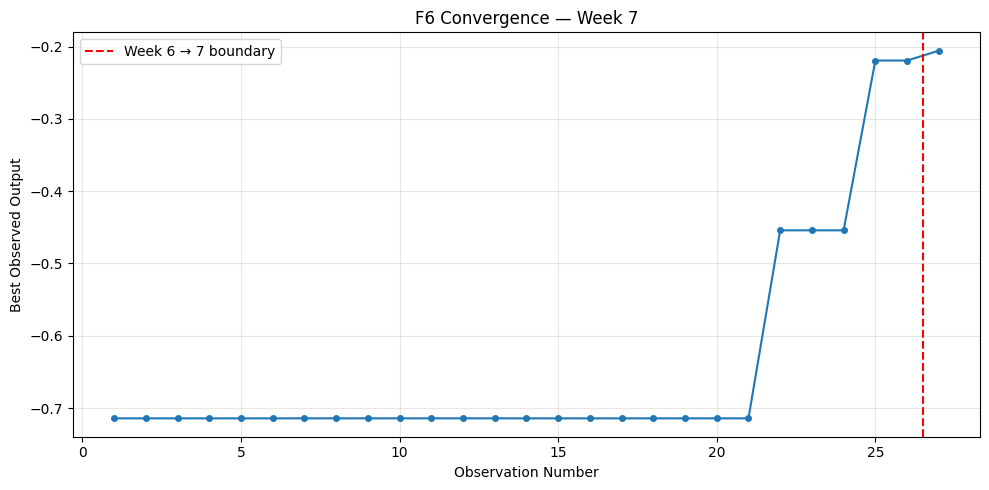

Running best at Week 6 end (sample 26): -0.219187
Running best at Week 7 end (sample 27): -0.205600


In [19]:
# ── Week 7: Convergence Plot ──
running_best = np.maximum.accumulate(y_raw)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_raw) + 1), running_best, marker="o", markersize=4, linewidth=1.5)
plt.axvline(x=26.5, color="red", linestyle="--", label="Week 6 → 7 boundary")
plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("F6 Convergence — Week 7")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 6 end (sample 26): {running_best[25]:.6f}")
print(f"Running best at Week 7 end (sample 27): {running_best[26]:.6f}")

In [17]:
# ── Week 7: Submission Query & Summary ──
import re
submission_point = np.clip(best_point, 0.0, 0.999999)
submission_query = "-".join(f"{v:.6f}" for v in submission_point)

print("=" * 60)
print("WEEK 7 SUBMISSION QUERY FOR FUNCTION 6")
print("=" * 60)
print(f"\n  {submission_query}\n")
print("=" * 60)

# Validation
parts = submission_query.split("-")
assert len(parts) == 5, f"Expected 5 dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds [0, 0.999999]"
assert re.match(r'^\d\.\d{6}-\d\.\d{6}-\d\.\d{6}-\d\.\d{6}-\d\.\d{6}$', submission_query), \
    f"Format mismatch: {submission_query}"
assert float(parts[4]) >= 0.10, f"x4 (milk) = {parts[4]} below feasibility bound 0.10!"
print("✓ Submission format validated")
print(f"✓ x4 (milk) = {parts[4]} ≥ 0.10")

# Summary
print(f"\nSurrogate:    SFGP Matérn-1.5 ARD (SingleTaskGP, Standardize(m=1) default)")
print(f"Acquisition:  qLogNoisyExpectedImprovement (q=4)")
print(f"Bounds:       x4≥0.10, others≥0.01 (feasibility-constrained)")
print(f"Selection:    Distance-based (mean ≥ median, farthest from data)")
print(f"Noise floor:  1e-2 (GreaterThan constraint)")
print(f"Noise init:   0.2 (20% of standardised Var(y)≈1.0)")
print(f"Clamping:     [0, 0.999999]")
print(f"Fitted lengthscales: [{', '.join(f'{l:.6f}' for l in ls)}]")
print(f"Fitted output scale: {os_val:.6f}")
print(f"Fitted noise:        {noise:.6f}")
print(f"Selected candidate #{best_among_filtered + 1} posterior mean: {pred_means[best_among_filtered]:.6f}")

WEEK 7 SUBMISSION QUERY FOR FUNCTION 6

  0.480990-0.380552-0.999999-0.671843-0.100000

✓ Submission format validated
✓ x4 (milk) = 0.100000 ≥ 0.10

Surrogate:    SFGP Matérn-1.5 ARD (SingleTaskGP, Standardize(m=1) default)
Acquisition:  qLogNoisyExpectedImprovement (q=4)
Bounds:       x4≥0.10, others≥0.01 (feasibility-constrained)
Selection:    Distance-based (mean ≥ median, farthest from data)
Noise floor:  1e-2 (GreaterThan constraint)
Noise init:   0.2 (20% of standardised Var(y)≈1.0)
Clamping:     [0, 0.999999]
Fitted lengthscales: [1.159700, 1.488752, 2.588093, 1.488291, 2.608905]
Fitted output scale: 2.478423
Fitted noise:        0.010000
Selected candidate #4 posterior mean: -0.311411


# Analysis

First run gives milk as 0 - this is clearly not a good sample - need to find an alternate maximim

Diagnosis:

The top-5 observations all have x4 (milk) < 0.043, with 3 data points at x4=0.000 exactly
The GP learned a strong anti-correlation (ρ=−0.758) with milk and pushes to the x4=0 boundary
Fitted noise ≈ 0 (at the 1e-8 floor) — the GP is interpolating exactly, leaving almost no uncertainty near known good points to drive exploration elsewhere
All fitted lengthscales > 1.0 — the GP sees the function as very smooth, over-smoothing the 5D space
I've completed the ambiguity scan against the spec. Two critical gaps need resolving before I can update the specification. Let me ask the most impactful question first:

Question 1 of up to 5

The current spec defines bounds as [0, 1]⁵ uniformly (FR-011), which allows any dimension to hit zero. The GP exploits this by driving x4 (milk) to the 0.0 boundary. We need a minimum feasible bound for x4 — and possibly for all dimensions.

## Week 7 — Interior Penalty Re-Scoring

Apply a soft interior penalty to discourage boundary-hugging candidates.
The penalty weight `w(x) = FLOOR + (1 - FLOOR) · ∏ᵢ sin(πxᵢ)^(2·STEEPNESS)`
re-scores candidates via rank-based combination (sign-invariant for all-negative outputs).

Because F6 outputs are **all negative**, the naive multiplicative approach (`pred_means × w(x)`)
would _promote_ boundary candidates instead of penalising them. Rank-based scoring is used instead:
each candidate is ranked by posterior mean and by interior weight independently, then ranks are summed.

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| STEEPNESS      | 1.0   | Strong boundary decay; rank-based scoring makes magnitude irrelevant |
| FLOOR          | 0.01  | Prevents zero-weight degeneracy at exact corners |

In [4]:
# ── Interior Penalty: Compute Weights ──
# Hyperparameters (tune these to control boundary avoidance)
STEEPNESS = 1.0   # Controls transition width; higher = narrower interior band
FLOOR     = 0.01  # Minimum weight at boundary; prevents zero-weight degeneracy

# Convert candidates to NumPy for penalty computation
cands_np = candidates.cpu().numpy()  # (4, 5)

# w(x) = FLOOR + (1 - FLOOR) * ∏ᵢ sin(πxᵢ)^(2·STEEPNESS)
interior_weight = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * cands_np) ** (2 * STEEPNESS), axis=1
)  # (4,)

# Validate
assert interior_weight.shape == (4,), f"Expected shape (4,), got {interior_weight.shape}"
assert np.all(interior_weight >= FLOOR), f"Weight below FLOOR: {interior_weight}"
assert np.all(interior_weight <= 1.0), f"Weight above 1.0: {interior_weight}"

# Display per-candidate weights
print("=== Interior Penalty Weights ===")
print(f"STEEPNESS = {STEEPNESS}, FLOOR = {FLOOR}")
print(f"{'Cand':>5} {'w(x)':>10} {'Label':>12}")
print("-" * 30)
for i in range(len(interior_weight)):
    label = "interior" if interior_weight[i] >= 0.5 else "boundary"
    print(f"{i+1:>5} {interior_weight[i]:>10.6f} {label:>12}")
print(f"\nMin weight: {interior_weight.min():.6f}, Max weight: {interior_weight.max():.6f}")

=== Interior Penalty Weights ===
STEEPNESS = 1.0, FLOOR = 0.01
 Cand       w(x)        Label
------------------------------
    1   0.010000     boundary
    2   0.016583     boundary
    3   0.140647     boundary
    4   0.010000     boundary

Min weight: 0.010000, Max weight: 0.140647


In [5]:
# ── Interior Penalty: Rank-Based Re-Scoring & Selection ──
# Rank-based scoring: sign-invariant — works correctly for all-negative outputs.
# Higher rank = more desirable.  No scipy dependency.
rank_mean   = np.argsort(np.argsort(pred_means)) + 1      # (4,) ranks 1–4, better mean → higher
rank_weight = np.argsort(np.argsort(interior_weight)) + 1  # (4,) ranks 1–4, more interior → higher
combined_score = rank_mean + rank_weight                    # range [2, 8]

# Median filter on combined score (replaces pred_means-based filter)
score_median = np.median(combined_score)
above_median = combined_score >= score_median
above_median_indices = np.where(above_median)[0]

# Distance-based selection among above-median candidates (unchanged from Week 7)
if len(above_median_indices) == 0:
    # Fallback: pick candidate with highest combined score
    best_ip_idx = int(np.argmax(combined_score))
    ip_reason = "fallback — highest combined score (none above median)"
else:
    above_median_dists = dists[above_median_indices].cpu().numpy()
    best_ip_idx = above_median_indices[np.argmax(above_median_dists)]
    ip_reason = "farthest from data among above-median (rank-filtered)"

best_point = candidates[best_ip_idx].cpu().numpy()

# ── Comparison Table ──
print("=== Rank-Based Re-Scoring (Interior Penalty) ===")
print(f"{'Cand':>5} {'pred_mean':>12} {'R(mean)':>8} {'w(x)':>10} {'R(w)':>6} {'Score':>6} {'Sel':>4}")
print("-" * 60)
for i in range(len(pred_means)):
    sel = " ◄" if i == best_ip_idx else "  "
    print(f"{i+1:>5} {pred_means[i]:>12.6f} {rank_mean[i]:>8d} "
          f"{interior_weight[i]:>10.6f} {rank_weight[i]:>6d} "
          f"{combined_score[i]:>6d} {sel}")

print(f"\nMedian combined score: {score_median:.1f}")
print(f"Above-median candidates: {list(above_median_indices + 1)}")
print(f"\n→ Selected candidate #{best_ip_idx + 1} ({ip_reason})")
print(f"  Coordinates: [{', '.join(f'{v:.6f}' for v in best_point)}]")
print(f"  Posterior mean: {pred_means[best_ip_idx]:.6f}")
print(f"  Interior weight: {interior_weight[best_ip_idx]:.6f}")
print(f"  Combined score: {combined_score[best_ip_idx]}")

# Validate feasibility
assert best_point.shape == (5,), f"Expected (5,), got {best_point.shape}"
assert np.all(best_point >= 0.01), f"Coordinate below 0.01: {best_point}"
assert best_point[4] >= 0.10, f"x4 (milk) = {best_point[4]:.6f} below 0.10!"
print(f"\n✓ Feasibility: all ≥ 0.01, x4 = {best_point[4]:.6f} ≥ 0.10")

=== Rank-Based Re-Scoring (Interior Penalty) ===
 Cand    pred_mean  R(mean)       w(x)   R(w)  Score  Sel
------------------------------------------------------------
    1    -0.316368        2   0.010000      1      3   
    2    -0.274951        4   0.016583      3      7   
    3    -1.334796        1   0.140647      4      5   
    4    -0.311411        3   0.010000      2      5  ◄

Median combined score: 5.0
Above-median candidates: [np.int64(2), np.int64(3), np.int64(4)]

→ Selected candidate #4 (farthest from data among above-median (rank-filtered))
  Coordinates: [0.480990, 0.380552, 0.999999, 0.671843, 0.100000]
  Posterior mean: -0.311411
  Interior weight: 0.010000
  Combined score: 5

✓ Feasibility: all ≥ 0.01, x4 = 0.100000 ≥ 0.10


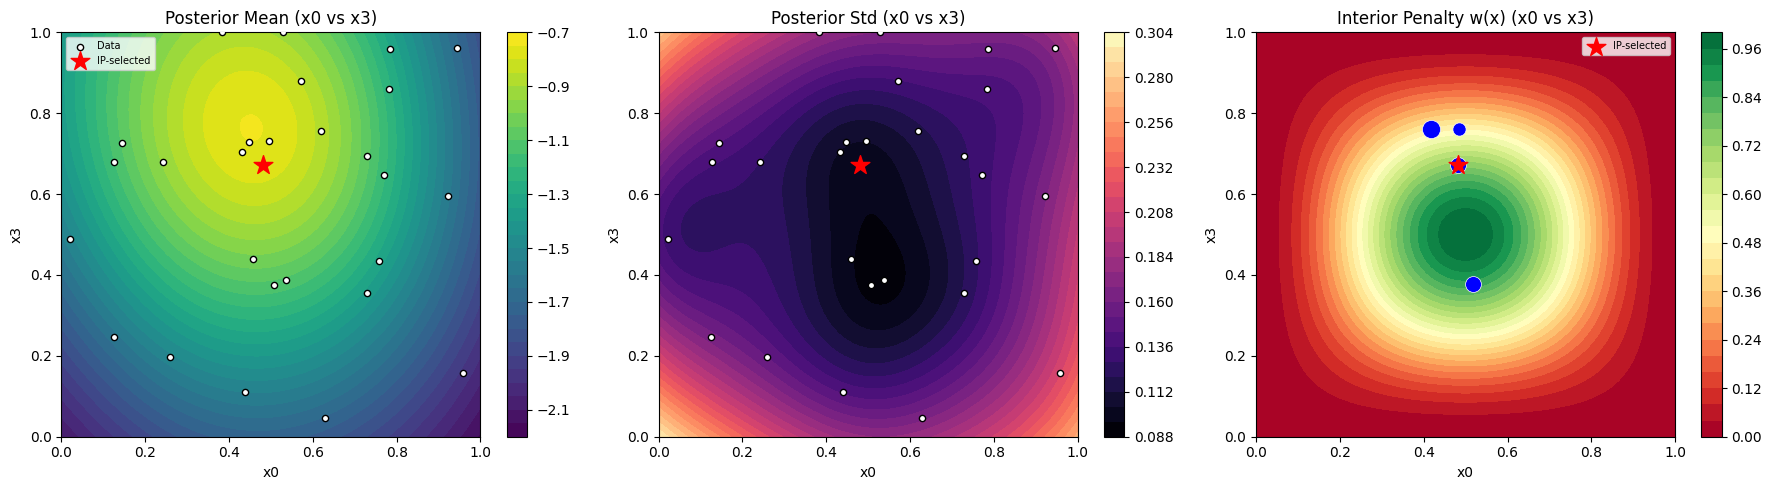

Visualised on top-2 ARD dims: x0 (1/ℓ=0.86), x3 (1/ℓ=0.67)


In [6]:
# ── Interior Penalty: 3-Panel Visualisation ──
# Panel 1: Posterior mean | Panel 2: Posterior std | Panel 3: Penalty w(x)
# All on 2D slice through top-2 ARD dimensions (highest 1/ℓ)

inv_ls = 1.0 / ls  # (5,)
top2 = np.argsort(inv_ls)[-2:][::-1]  # 2 most relevant dims
dim_a, dim_b = top2[0], top2[1]

# Build 80×80 evaluation grid — other dims held at 0.5
grid = np.linspace(0, 1, 80)
xx, yy = np.meshgrid(grid, grid)
base = np.full((80 * 80, 5), 0.5)
base[:, dim_a] = xx.ravel()
base[:, dim_b] = yy.ravel()

# GP posterior on grid
grid_t = torch.tensor(base, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    post_grid = best_model.posterior(grid_t)
    mean_grid = post_grid.mean.squeeze(-1).cpu().numpy().reshape(80, 80)
    std_grid  = post_grid.variance.squeeze(-1).sqrt().cpu().numpy().reshape(80, 80)

# Penalty surface on grid
w_grid = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * base) ** (2 * STEEPNESS), axis=1
).reshape(80, 80)

# Training data & candidates projected onto top-2 dims
X_train_np = X_train.cpu().numpy()
cands_proj = cands_np[:, [dim_a, dim_b]]
train_proj = X_train_np[:, [dim_a, dim_b]]
best_proj  = best_point[[dim_a, dim_b]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Posterior Mean
im1 = axes[0].contourf(xx, yy, mean_grid, levels=30, cmap='viridis')
axes[0].scatter(train_proj[:, 0], train_proj[:, 1], c='white', edgecolors='black', s=20, zorder=3, label='Data')
axes[0].scatter(*best_proj, marker='*', c='red', s=200, zorder=4, label='IP-selected')
axes[0].set_title(f"Posterior Mean (x{dim_a} vs x{dim_b})")
axes[0].set_xlabel(f"x{dim_a}"); axes[0].set_ylabel(f"x{dim_b}")
fig.colorbar(im1, ax=axes[0])
axes[0].legend(fontsize=7)

# Panel 2: Posterior Std
im2 = axes[1].contourf(xx, yy, std_grid, levels=30, cmap='magma')
axes[1].scatter(train_proj[:, 0], train_proj[:, 1], c='white', edgecolors='black', s=20, zorder=3)
axes[1].scatter(*best_proj, marker='*', c='red', s=200, zorder=4)
axes[1].set_title(f"Posterior Std (x{dim_a} vs x{dim_b})")
axes[1].set_xlabel(f"x{dim_a}"); axes[1].set_ylabel(f"x{dim_b}")
fig.colorbar(im2, ax=axes[1])

# Panel 3: Interior Penalty w(x) with candidates
im3 = axes[2].contourf(xx, yy, w_grid, levels=30, cmap='RdYlGn', vmin=FLOOR, vmax=1.0)
# Scatter candidates — size proportional to combined_score
for i in range(cands_proj.shape[0]):
    marker_size = 30 + combined_score[i] * 20  # larger = higher score
    axes[2].scatter(cands_proj[i, 0], cands_proj[i, 1], c='blue', s=marker_size,
                    edgecolors='white', zorder=3, linewidths=0.5)
axes[2].scatter(*best_proj, marker='*', c='red', s=200, zorder=4, label='IP-selected')
axes[2].set_title(f"Interior Penalty w(x) (x{dim_a} vs x{dim_b})")
axes[2].set_xlabel(f"x{dim_a}"); axes[2].set_ylabel(f"x{dim_b}")
fig.colorbar(im3, ax=axes[2])
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()
print(f"Visualised on top-2 ARD dims: x{dim_a} (1/ℓ={inv_ls[dim_a]:.2f}), x{dim_b} (1/ℓ={inv_ls[dim_b]:.2f})")

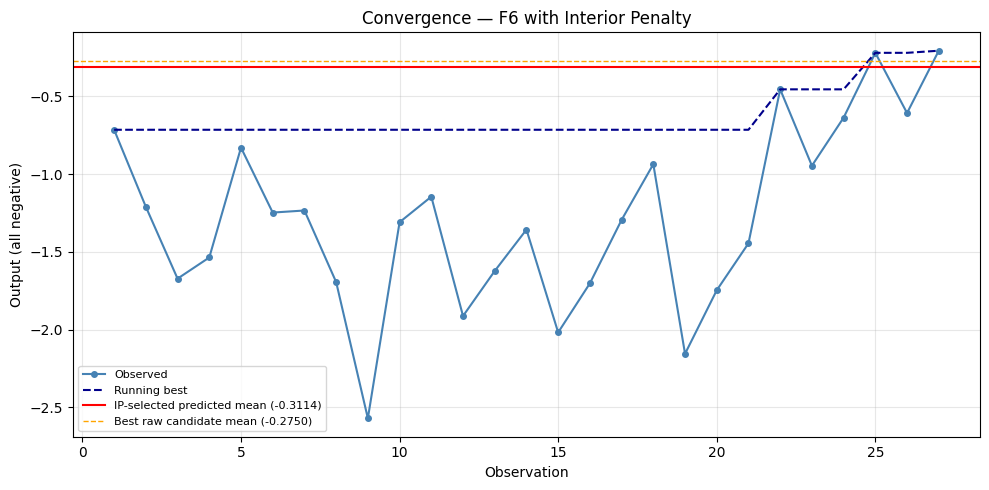

Running best: -0.205600
IP-selected predicted mean: -0.311411
Raw best candidate mean:    -0.274951 (candidate #2)
→ Interior penalty changed selection from #2 to #4


In [7]:
# ── Interior Penalty: Convergence Plot ──
running_best = np.maximum.accumulate(y_raw)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_raw) + 1), y_raw, 'o-', color='steelblue', markersize=4, label='Observed')
plt.plot(range(1, len(running_best) + 1), running_best, '--', color='darkblue', linewidth=1.5, label='Running best')

# IP-selected predicted mean
ip_pred = pred_means[best_ip_idx]
plt.axhline(ip_pred, color='red', linestyle='-', linewidth=1.5,
            label=f'IP-selected predicted mean ({ip_pred:.4f})')

# Best raw candidate mean (for comparison)
raw_best_pred = pred_means.max()
raw_best_idx = int(np.argmax(pred_means))
if raw_best_idx != best_ip_idx:
    plt.axhline(raw_best_pred, color='orange', linestyle='--', linewidth=1.0,
                label=f'Best raw candidate mean ({raw_best_pred:.4f})')

plt.xlabel('Observation')
plt.ylabel('Output (all negative)')
plt.title('Convergence — F6 with Interior Penalty')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best: {running_best[-1]:.6f}")
print(f"IP-selected predicted mean: {ip_pred:.6f}")
if raw_best_idx != best_ip_idx:
    print(f"Raw best candidate mean:    {raw_best_pred:.6f} (candidate #{raw_best_idx + 1})")
    print(f"→ Interior penalty changed selection from #{raw_best_idx + 1} to #{best_ip_idx + 1}")

In [8]:
# ── Interior Penalty: Submission Query ──
import re

# Clip to [0, 0.999999] and format
submission_point = np.clip(best_point, 0.0, 0.999999)
query = "-".join(f"{v:.6f}" for v in submission_point)

# Validate format
assert re.match(r'^(0\.\d{6}-){4}0\.\d{6}$', query), f"Bad format: {query}"
assert submission_point.shape == (5,), f"Expected 5D, got {submission_point.shape}"
assert np.all(submission_point >= 0.01), f"Coordinate below 0.01: {submission_point}"
assert submission_point[4] >= 0.10, f"x4 (milk) = {submission_point[4]:.6f} below 0.10!"

print("=" * 60)
print("SUBMISSION QUERY (F6 — Interior Penalty)")
print("=" * 60)
print(f"\n  {query}\n")

# Penalty metadata
print(f"  STEEPNESS = {STEEPNESS}")
print(f"  FLOOR     = {FLOOR}")
print(f"  Interior weight: {interior_weight[best_ip_idx]:.6f}")
print(f"  Combined score:  {combined_score[best_ip_idx]} / 8")
print(f"  Posterior mean:   {pred_means[best_ip_idx]:.6f}")

# Compare raw vs penalty selection
raw_best_idx = int(np.argmax(pred_means))
if raw_best_idx != best_ip_idx:
    print(f"\n  ⚠ Penalty CHANGED selection:")
    print(f"    Raw best:     candidate #{raw_best_idx + 1} (mean={pred_means[raw_best_idx]:.6f}, w={interior_weight[raw_best_idx]:.6f})")
    print(f"    IP-selected:  candidate #{best_ip_idx + 1} (mean={pred_means[best_ip_idx]:.6f}, w={interior_weight[best_ip_idx]:.6f})")
else:
    print(f"\n  ✓ Penalty confirmed raw-best candidate #{best_ip_idx + 1} (already interior)")

print(f"\n  Submission coordinates:")
for i, (name, val) in enumerate(zip(['flour', 'sugar', 'eggs', 'butter', 'milk'], submission_point)):
    bound = '≥ 0.10' if i == 4 else '≥ 0.01'
    status = '✓' if (val >= 0.10 if i == 4 else val >= 0.01) else '✗'
    print(f"    x{i} ({name:>6s}) = {val:.6f}  {status} {bound}")
print("=" * 60)

SUBMISSION QUERY (F6 — Interior Penalty)

  0.480990-0.380552-0.999999-0.671843-0.100000

  STEEPNESS = 1.0
  FLOOR     = 0.01
  Interior weight: 0.010000
  Combined score:  5 / 8
  Posterior mean:   -0.311411

  ⚠ Penalty CHANGED selection:
    Raw best:     candidate #2 (mean=-0.274951, w=0.016583)
    IP-selected:  candidate #4 (mean=-0.311411, w=0.010000)

  Submission coordinates:
    x0 ( flour) = 0.480990  ✓ ≥ 0.01
    x1 ( sugar) = 0.380552  ✓ ≥ 0.01
    x2 (  eggs) = 0.999999  ✓ ≥ 0.01
    x3 (butter) = 0.671843  ✓ ≥ 0.01
    x4 (  milk) = 0.100000  ✓ ≥ 0.10
